<a href="https://colab.research.google.com/github/SofiaDomeli/Neural_Network_HS/blob/bc/RedesNeurais_BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> 🧠 Rede Neural 🧠 </center>

### 1. Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from tensorflow.keras.initializers import GlorotUniform # type: ignore
from sklearn.datasets import load_breast_cancer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

### 2. Variáveis e Ambiente

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data = data.data,
                       columns = data.feature_names)

atributos = df
resposta = np.array(data.target)

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Pré-processamento

In [3]:
# Resposta
label_encoder = LabelEncoder()

# Atributos
preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', OrdinalEncoder(), make_column_selector(dtype_include=['object', 'bool'])),
    ],
    remainder='passthrough', # Preserva as colunas que não foram transformadas
    verbose_feature_names_out = False
)

In [4]:
atributos = pd.DataFrame(data=preprocessador.fit_transform(atributos), columns=preprocessador.get_feature_names_out())
resposta = label_encoder.fit_transform(resposta)

#### 3.1 Divisão treino e teste

In [5]:
atributos_treino, atributos_teste, resposta_treino, resposta_teste = train_test_split(atributos, resposta, test_size=0.2, random_state=42)

### 4. Implementação - Hidden Layers

In [6]:
# modelo sequencial: 2 neurônios na oculta, 1 na saída
model = Sequential()
model.add(Dense(2, input_dim=len(atributos.columns), activation='sigmoid',
                kernel_initializer=GlorotUniform(seed=42)))
model.add(Dense(1, activation='sigmoid',
                kernel_initializer=GlorotUniform(seed=42)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# compile - 'contrato de treino'
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### 5. Treino do modelo

In [8]:
# treinamento com armazenamneto do historico
history = model.fit(atributos_treino, resposta_treino, epochs=100, verbose=0)

### 6. Avaliação do modelo

In [9]:
# avaliacao final
loss, accuracy = model.evaluate(atributos_teste, resposta_teste, verbose=0)
print(f'\n--> Avaliação final no conjunto de treino')
print(f'Loss final: {loss:.2f}')
print(f'Acúracia final: {accuracy:.2f}')

# historico
print(f'\nNúmero de épocas treinadas: {len(history.history["loss"])}')
print(f'Último loss registrado: {history.history["loss"][-1]:.4f}')
print(f'Últimaa acurácia registrada: {history.history["accuracy"][-1]:.4f}')


--> Avaliação final no conjunto de treino
Loss final: 0.66
Acúracia final: 0.62

Número de épocas treinadas: 100
Último loss registrado: 0.6598
Últimaa acurácia registrada: 0.6286


#### 6.1 Gráfico de Avalição [ Em Desenvolvimento ]

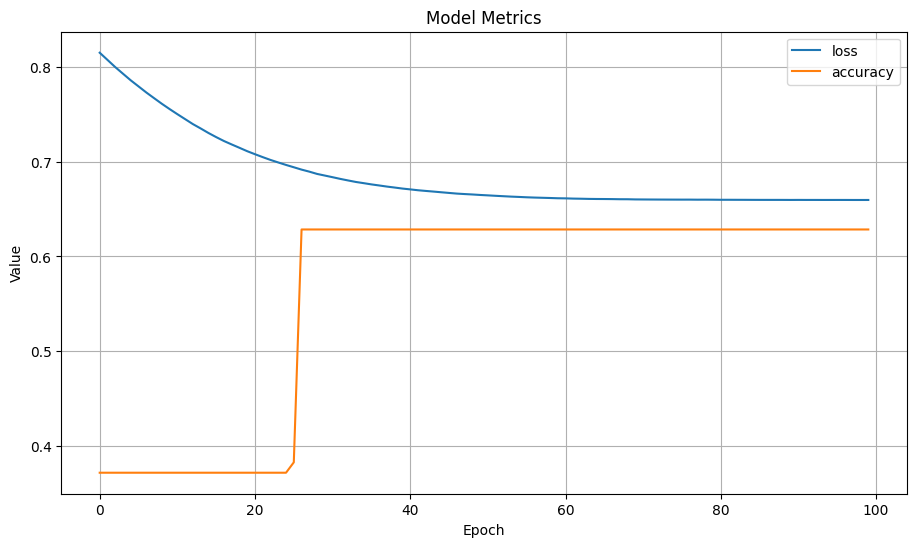

In [10]:
plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.title('Model Metrics')
plt.ylabel('Value')
plt.xlabel('Epoch')
plt.legend()
plt.grid()
plt.show()

In [11]:
from itertools import product

def criar_modelo(neuronios=2, camadas=1, ativacao="sigmoid", otimizador="adam"):
    model = Sequential()
    # primeira camada oculta
    model.add(Dense(neuronios, input_dim=atributos_treino.shape[1],
                    activation=ativacao, kernel_initializer=GlorotUniform(seed=42)))
    # camadas adicionais
    for _ in range(camadas - 1):
        model.add(Dense(neuronios, activation=ativacao,
                        kernel_initializer=GlorotUniform(seed=42)))
    # saída
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer=otimizador, loss="binary_crossentropy", metrics=["accuracy"])
    return model


param_grid = {
    "neuronios": [2, 4, 8, 16, 32],
    "camadas": [1, 2, 3],
    "ativacao": ["sigmoid", "relu", "tanh"],
    "otimizador": ["adam", "sgd"],
    "epochs": [100]
}

melhor_acc = 0
melhores_params = None
historico_resultados = []

for valores in product(*param_grid.values()):
    params = dict(zip(param_grid, valores))

    model = criar_modelo(
        neuronios=params["neuronios"],
        camadas=params["camadas"],
        ativacao=params["ativacao"],
        otimizador=params["otimizador"]
    )

    history = model.fit(
        atributos_treino, resposta_treino,
        epochs=100,
        verbose=0
    )

    loss, acc = model.evaluate(atributos_teste, resposta_teste, verbose=0)

    historico_resultados.append((params, acc))

    if acc > melhor_acc:
        melhor_acc = acc
        melhores_params = params

    print(f"Testado: {params} -> Acurácia teste: {acc:.4f}")

print("\nMelhores parâmetros encontrados:")
print(melhores_params)
print(f"Acurácia no teste: {melhor_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 1, 'ativacao': 'sigmoid', 'otimizador': 'adam', 'epochs': 100} -> Acurácia teste: 0.6228


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 2, 'camadas': 1, 'ativacao': 'sigmoid', 'otimizador': 'sgd', 'epochs': 100} -> Acurácia teste: 0.6228


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Testado: {'neuronios': 32, 'camadas': 3, 'ativacao': 'relu', 'otimizador': 'sgd', 'epochs': 100} -> Acurácia teste: 0.6316


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 32, 'camadas': 3, 'ativacao': 'tanh', 'otimizador': 'adam', 'epochs': 100} -> Acurácia teste: 0.9474


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testado: {'neuronios': 32, 'camadas': 3, 'ativacao': 'tanh', 'otimizador': 'sgd', 'epochs': 100} -> Acurácia teste: 0.6228

Melhores parâmetros encontrados:
{'neuronios': 32, 'camadas': 1, 'ativacao': 'relu', 'otimizador': 'adam', 'epochs': 100}
Acurácia no teste: 0.9825
